Data Loaded:


,Participant,Accuracy,ReactionTime_s
0,1,97.2,1.70
1,2,97.2,1.67
2,3,97.8,2.03
3,4,98.8,2.25
4,5,100.0,1.03
5,6,99.2,1.46
6,7,98.2,1.07
7,8,98.6,1.29
8,9,93.1,2.52
9,10,96.9,1.40


Cluster Centroids (Accuracy, ReactionTime):
[[98.43571429  1.55785714]
 [90.9         2.545     ]]


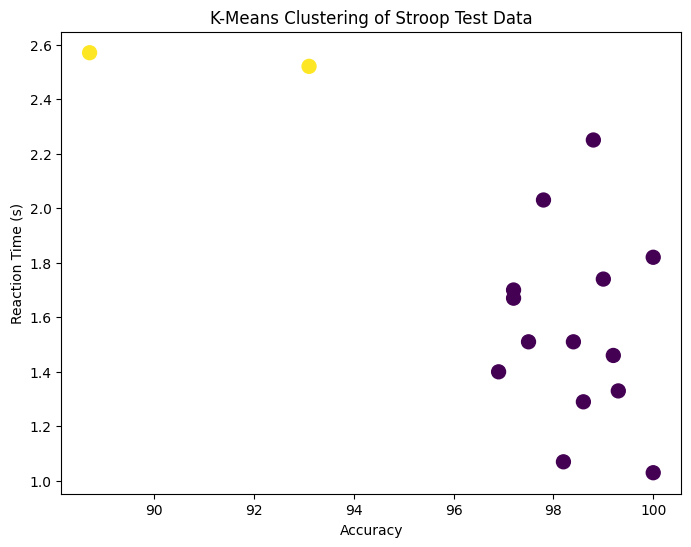


Cluster Labels Added to DataFrame:


,Participant,Accuracy,ReactionTime_s,ClusterLabel
0,1,97.2,1.70,0
1,2,97.2,1.67,0
2,3,97.8,2.03,0
3,4,98.8,2.25,0
4,5,100.0,1.03,0
5,6,99.2,1.46,0
6,7,98.2,1.07,0
7,8,98.6,1.29,0
8,9,93.1,2.52,1
9,10,96.9,1.40,0


Confusion Matrix - SVM:
[[4 0]
 [0 0]]


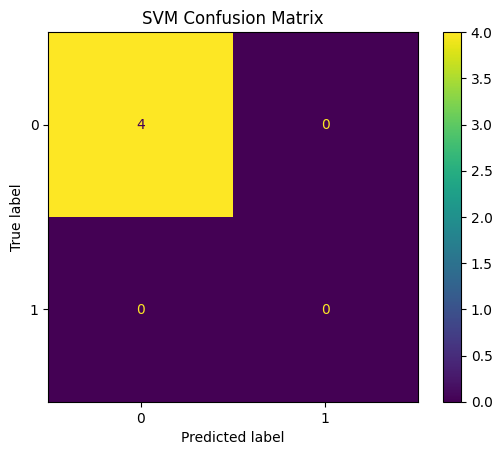

Confusion Matrix - Decision Tree:
[[4 0]
 [0 0]]


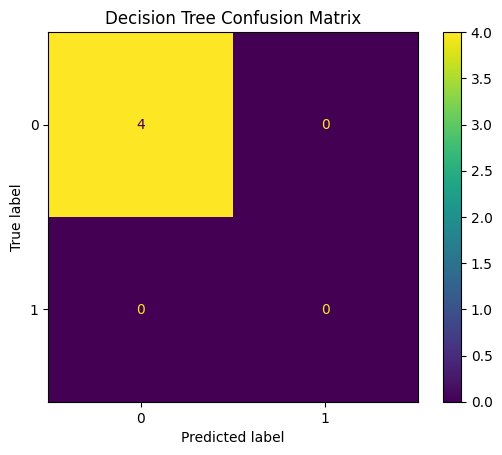

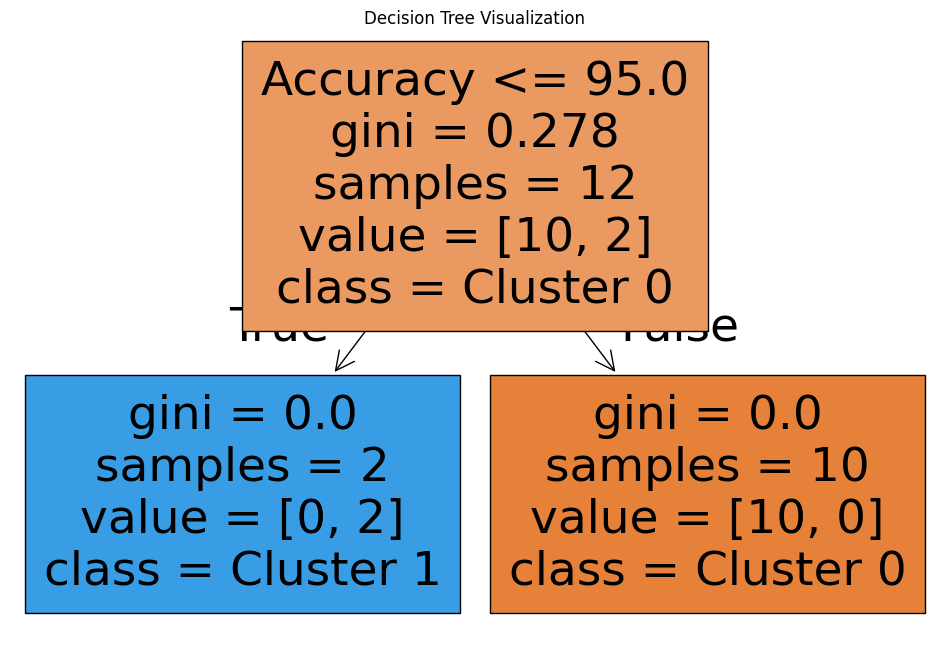

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

import os
os.getcwd()
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 1\\data\\stroop_data_template.csv')
print("Data Loaded:")
display(df.head(16))




scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Accuracy', 'ReactionTime_s']])


kmeans = KMeans(n_clusters=2, random_state=42)
df['ClusterLabel'] = kmeans.fit_predict(scaled_features)

# Cluster centroids (optional)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print("Cluster Centroids (Accuracy, ReactionTime):")
print(centroids)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(df['Accuracy'], df['ReactionTime_s'], c=df['ClusterLabel'], cmap='viridis', s=100)
plt.xlabel('Accuracy')
plt.ylabel('Reaction Time (s)')
plt.title('K-Means Clustering of Stroop Test Data')
plt.show()

# Step 2 complete - cluster labels added
print("\nCluster Labels Added to DataFrame:")
display(df)
# Step 3: SVM and Decision Tree (Fixed for single label warning)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Features & Target
X = df[['Accuracy', 'ReactionTime_s']]
y = df['ClusterLabel']

# Train-Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- SVM Classifier ----
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Confusion matrix for SVM (fixed)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=[0,1])
print("Confusion Matrix - SVM:")
print(cm_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=[0,1]).plot()
plt.title("SVM Confusion Matrix")
plt.show()

# ---- Decision Tree Classifier ----
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Confusion matrix for Decision Tree (fixed)
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[0,1])
print("Confusion Matrix - Decision Tree:")
print(cm_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=[0,1]).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Decision Tree visualization
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=['Accuracy','ReactionTime_s'], class_names=['Cluster 0','Cluster 1'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()
